# Stock Screener — Factor Analysis

End-to-end equity screening pipeline built on a normalised PostgreSQL database of S&P 500 price and fundamental data.  
Five standard quant factors are computed directly in SQL using window functions and CTEs, then visualised below.

**Universe:** 55 large-cap US equities · 11 GICS sectors  
**Data source:** Yahoo Finance via yfinance · 2 years daily OHLCV + quarterly financials

In [1]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings('ignore')

engine = create_engine(os.environ['DATABASE_URL'])
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

## 1. Rolling 20-Day Volatility

Annualised realised volatility computed as a rolling 20-day coefficient of variation, scaled by √252.  
**SQL:** `STDDEV` window function with a `ROWS BETWEEN` frame, `PARTITION BY security_id`.

In [2]:
sql_vol = """
SELECT
    s.ticker,
    p.date,
    ROUND((
        STDDEV(p.adj_close) OVER (
            PARTITION BY p.security_id
            ORDER BY p.date
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        )
        / NULLIF(AVG(p.adj_close) OVER (
            PARTITION BY p.security_id
            ORDER BY p.date
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        ), 0) * SQRT(252) * 100)::numeric, 2
    ) AS vol_pct
FROM daily_prices p
JOIN securities   s USING (security_id)
WHERE s.ticker IN ('AAPL', 'NVDA', 'JPM', 'XOM', 'TSLA')
  AND p.date >= CURRENT_DATE - INTERVAL '1 year'
ORDER BY s.ticker, p.date
"""

vol_df = pd.read_sql(sql_vol, engine)
vol_df['date'] = pd.to_datetime(vol_df['date'])
vol_df.head(10)

,ticker,date,vol_pct
0,AAPL,2025-05-12,NaN
1,AAPL,2025-05-13,11.34
2,AAPL,2025-05-14,8.26
3,AAPL,2025-05-15,7.08
4,AAPL,2025-05-16,6.47
5,AAPL,2025-05-19,10.81
6,AAPL,2025-05-20,15.96
7,AAPL,2025-05-21,27.27
8,AAPL,2025-05-22,33.00
9,AAPL,2025-05-23,45.06


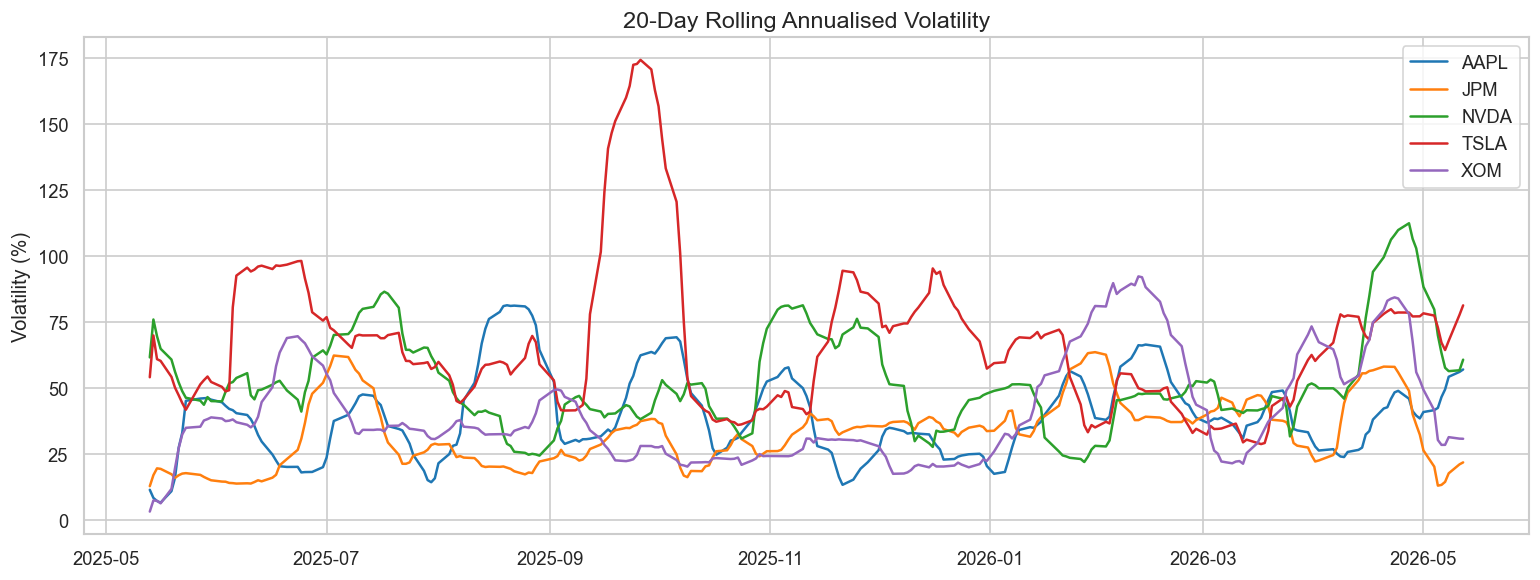

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
for ticker, grp in vol_df.groupby('ticker'):
    ax.plot(grp['date'], grp['vol_pct'], label=ticker, linewidth=1.5)
ax.set_title('20-Day Rolling Annualised Volatility', fontsize=14)
ax.set_ylabel('Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** TSLA and NVDA consistently show the highest realised volatility — typical for high-beta growth names. JPM and XOM cluster at the lower end, reflecting their more stable cash flows. Spikes correspond to earnings dates and macro events. A vol-targeting strategy would systematically underweight the high-vol names to maintain constant portfolio risk.

## 2. Momentum Screen (12-1 Month)

The Jegadeesh-Titman momentum factor: 12-month return skipping the most recent month (to avoid short-term reversal contamination).  
**SQL:** Conditional aggregation (`MAX CASE`), dual `RANK` with `PARTITION BY`, ratio derivation.

In [4]:
sql_mom = """
WITH price_points AS (
    SELECT
        security_id,
        MAX(CASE WHEN date BETWEEN CURRENT_DATE - INTERVAL '12 months'
                                AND CURRENT_DATE - INTERVAL '11 months'
                 THEN adj_close END) AS price_12m,
        MAX(CASE WHEN date BETWEEN CURRENT_DATE - INTERVAL '1 month'
                                AND CURRENT_DATE
                 THEN adj_close END) AS price_1m
    FROM daily_prices
    WHERE date >= CURRENT_DATE - INTERVAL '12 months'
    GROUP BY security_id
)
SELECT
    s.ticker,
    sec.sector_name,
    ROUND((p.price_1m / NULLIF(p.price_12m, 0) - 1) * 100, 2) AS momentum_pct,
    RANK() OVER (ORDER BY p.price_1m / NULLIF(p.price_12m, 0) DESC)                    AS universe_rank,
    RANK() OVER (PARTITION BY s.sector_id
                 ORDER BY p.price_1m / NULLIF(p.price_12m, 0) DESC)                    AS sector_rank
FROM price_points p
JOIN securities   s   USING (security_id)
JOIN sectors      sec USING (sector_id)
WHERE p.price_12m IS NOT NULL AND p.price_1m IS NOT NULL
ORDER BY momentum_pct DESC
"""

mom_df = pd.read_sql(sql_mom, engine).dropna(subset=['momentum_pct'])
mom_df.head(10)

,ticker,sector_name,momentum_pct,universe_rank,sector_rank
0,CAT,Industrials,158.02,1,1
1,GOOGL,Communication Services,124.92,2,1
2,NEM,Basic Materials,117.63,3,1
3,FCX,Basic Materials,68.11,4,2
4,SLB,Energy,62.45,5,1
5,JNJ,Healthcare,56.19,6,1
6,GS,Financial Services,53.69,7,1
7,NVDA,Technology,52.29,8,1
8,MRK,Healthcare,52.18,9,2
9,MS,Financial Services,49.44,10,2


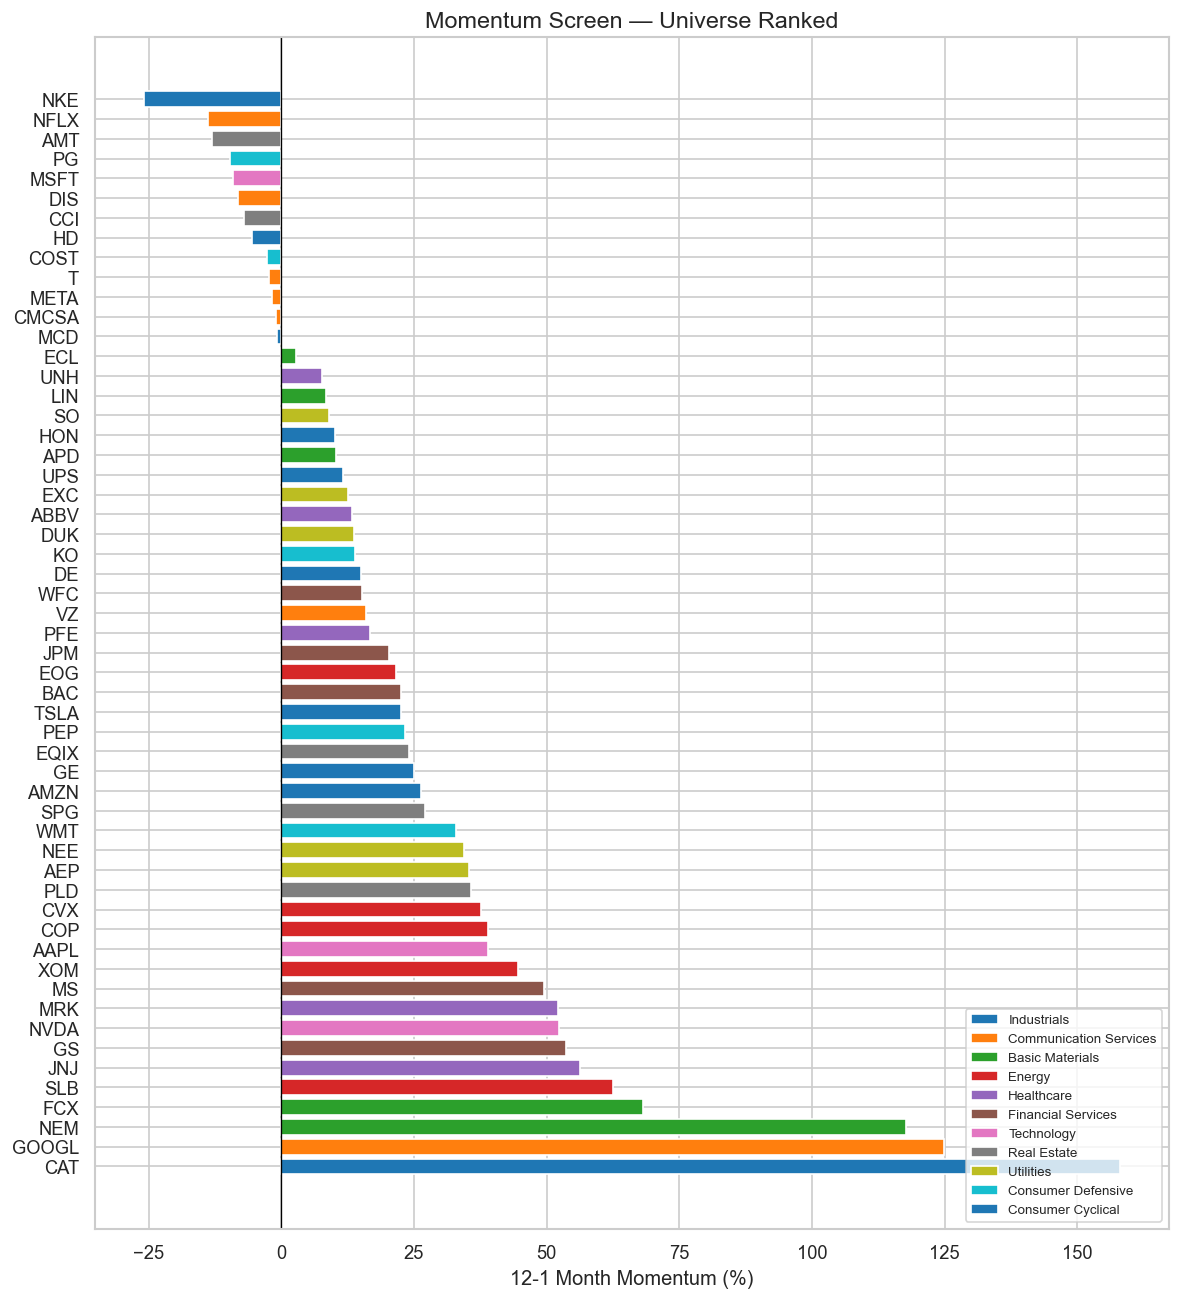

In [5]:
sectors = mom_df['sector_name'].unique()
palette = dict(zip(sectors, sns.color_palette('tab10', n_colors=len(sectors))))
colors  = mom_df['sector_name'].map(palette)

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(mom_df['ticker'], mom_df['momentum_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('12-1 Month Momentum (%)')
ax.set_title('Momentum Screen — Universe Ranked', fontsize=14)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=palette[s], label=s) for s in sectors]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

**Interpretation:** The top-ranked names by momentum are long candidates in a trend-following strategy; the bottom-ranked are potential underweights or shorts. Sector clustering reveals macro tailwinds — Technology and Consumer Discretionary names often dominate the top decile in risk-on regimes. Defensive sectors (Utilities, Consumer Staples) tend to cluster near zero, reflecting their low-beta, non-trending nature.

## 3. Value Screen (P/E and P/B)

Price-to-earnings and price-to-book ratios from the most recent quarter, with quintile bucketing.  
**SQL:** `DISTINCT ON` for latest-row-per-group, ratio derivation across joined tables, `NTILE` bucketing.

In [6]:
sql_val = """
WITH latest_price AS (
    SELECT DISTINCT ON (security_id)
        security_id, adj_close AS current_price
    FROM daily_prices
    ORDER BY security_id, date DESC
),
latest_fund AS (
    SELECT DISTINCT ON (security_id)
        security_id, eps, book_value_per_share
    FROM fundamentals
    WHERE eps IS NOT NULL
    ORDER BY security_id, fiscal_quarter DESC
)
SELECT
    s.ticker,
    sec.sector_name,
    ROUND(lp.current_price / NULLIF(lf.eps, 0), 1)                    AS pe_ratio,
    ROUND(lp.current_price / NULLIF(lf.book_value_per_share, 0), 2)   AS pb_ratio,
    NTILE(5) OVER (ORDER BY lp.current_price / NULLIF(lf.eps, 0))     AS pe_quintile
FROM latest_price lp
JOIN latest_fund  lf  USING (security_id)
JOIN securities   s   USING (security_id)
JOIN sectors      sec USING (sector_id)
WHERE lp.current_price / NULLIF(lf.eps, 0) BETWEEN 0 AND 100
ORDER BY pe_ratio
"""

val_df = pd.read_sql(sql_val, engine).dropna()
val_df.head(10)

,ticker,sector_name,pe_ratio,pb_ratio,pe_quintile
0,SPG,Real Estate,22.0,12.84,1
1,EOG,Energy,36.1,2.32,1
2,NEM,Basic Materials,39.8,3.68,1
3,VZ,Communication Services,39.9,1.94,1
4,CMCSA,Communication Services,41.0,1.01,1
5,BAC,Financial Services,45.3,1.20,1
6,WFC,Financial Services,46.4,1.29,1
7,UPS,Industrials,46.7,5.15,2
8,T,Communication Services,47.6,1.61,2
9,JPM,Financial Services,51.2,2.24,2


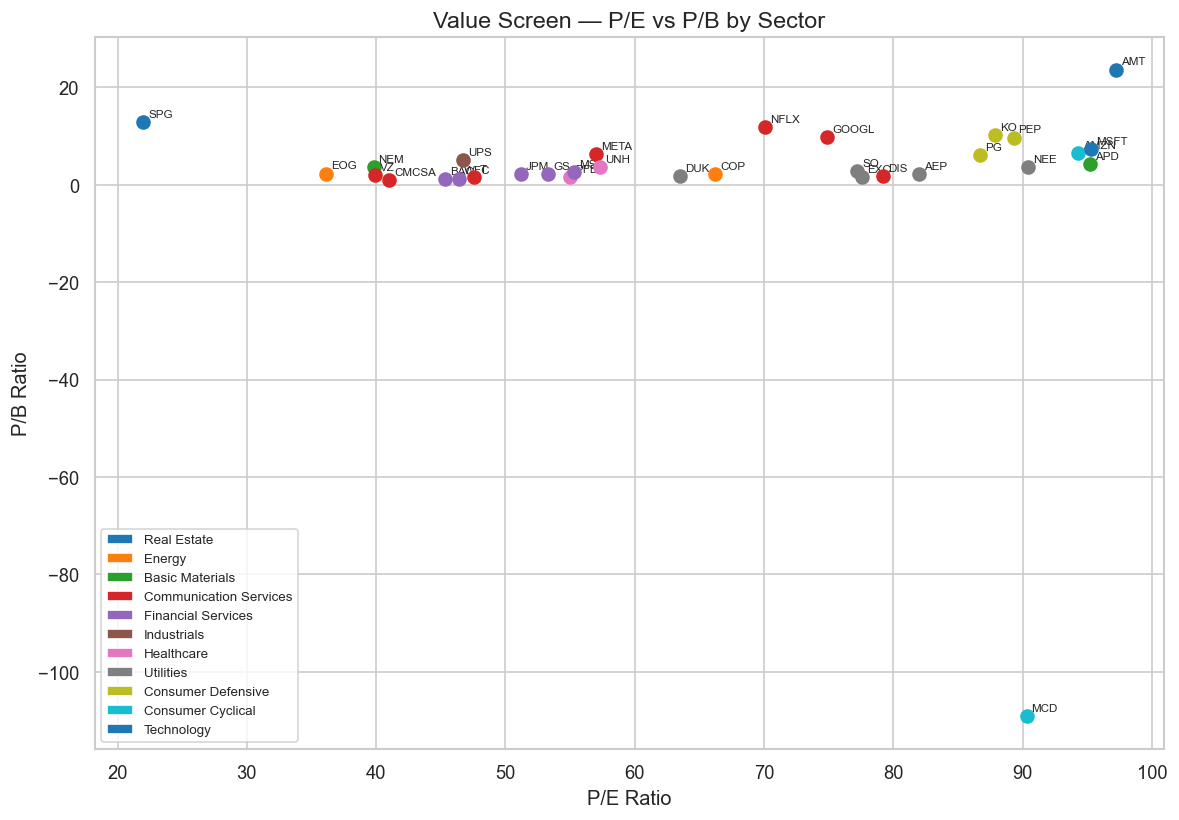

In [7]:
sectors = val_df['sector_name'].unique()
palette = dict(zip(sectors, sns.color_palette('tab10', n_colors=len(sectors))))

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in val_df.iterrows():
    ax.scatter(row['pe_ratio'], row['pb_ratio'],
               color=palette[row['sector_name']], s=60, zorder=3)
    ax.annotate(row['ticker'], (row['pe_ratio'], row['pb_ratio']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=palette[s], label=s) for s in sectors]
ax.legend(handles=legend_handles, fontsize=8)
ax.set_xlabel('P/E Ratio')
ax.set_ylabel('P/B Ratio')
ax.set_title('Value Screen — P/E vs P/B by Sector', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:** Stocks in the bottom-left quadrant (low P/E and low P/B) are cheapest on both metrics simultaneously — classic deep value candidates. Financials and Energy names tend to cluster here. Technology trades at a significant premium on both axes, reflecting high growth expectations. Stocks cheap on P/E but expensive on P/B (or vice versa) warrant further investigation — this often flags asset-heavy businesses or one-off earnings distortions.

## 4. Earnings Surprise

EPS actual vs. analyst estimate for the most recent reported quarter, with beat/miss classification.  
**SQL:** Derived percentage column, `CASE` expression, `DISTINCT ON` for latest quarter per ticker.

In [8]:
sql_surp = """
WITH surprises AS (
    SELECT
        security_id,
        fiscal_quarter,
        ROUND(
            (eps_actual - eps_estimate) / NULLIF(ABS(eps_estimate), 0) * 100, 1
        ) AS surprise_pct,
        CASE
            WHEN (eps_actual - eps_estimate) / NULLIF(ABS(eps_estimate), 0) >  0.05 THEN 'large beat'
            WHEN (eps_actual - eps_estimate) / NULLIF(ABS(eps_estimate), 0) >  0    THEN 'beat'
            WHEN (eps_actual - eps_estimate) / NULLIF(ABS(eps_estimate), 0) > -0.05 THEN 'miss'
            ELSE 'large miss'
        END AS outcome
    FROM analyst_estimates
    WHERE eps_estimate IS NOT NULL AND eps_actual IS NOT NULL
)
SELECT DISTINCT ON (s.ticker)
    s.ticker, sec.sector_name,
    sur.fiscal_quarter, sur.surprise_pct, sur.outcome
FROM surprises  sur
JOIN securities s   USING (security_id)
JOIN sectors    sec USING (sector_id)
ORDER BY s.ticker, sur.fiscal_quarter DESC
"""

surp_df = pd.read_sql(sql_surp, engine).dropna(subset=['surprise_pct'])
surp_df = surp_df.sort_values('surprise_pct')
surp_df.head(10)

,ticker,sector_name,fiscal_quarter,surprise_pct,outcome
46,SPG,Real Estate,2026-03-31,-18.0,large miss
18,EQIX,Real Estate,2026-03-31,-3.8,miss
37,NFLX,Communication Services,2026-03-31,-1.4,miss
1,ABBV,Healthcare,2026-03-31,-0.8,miss
16,ECL,Basic Materials,2026-03-31,0.2,beat
11,COST,Consumer Defensive,2026-02-28,0.8,beat
26,JNJ,Healthcare,2026-03-31,0.8,beat
52,WFC,Financial Services,2026-03-31,1.0,beat
44,SLB,Energy,2026-03-31,1.1,beat
29,LIN,Basic Materials,2026-03-31,1.4,beat


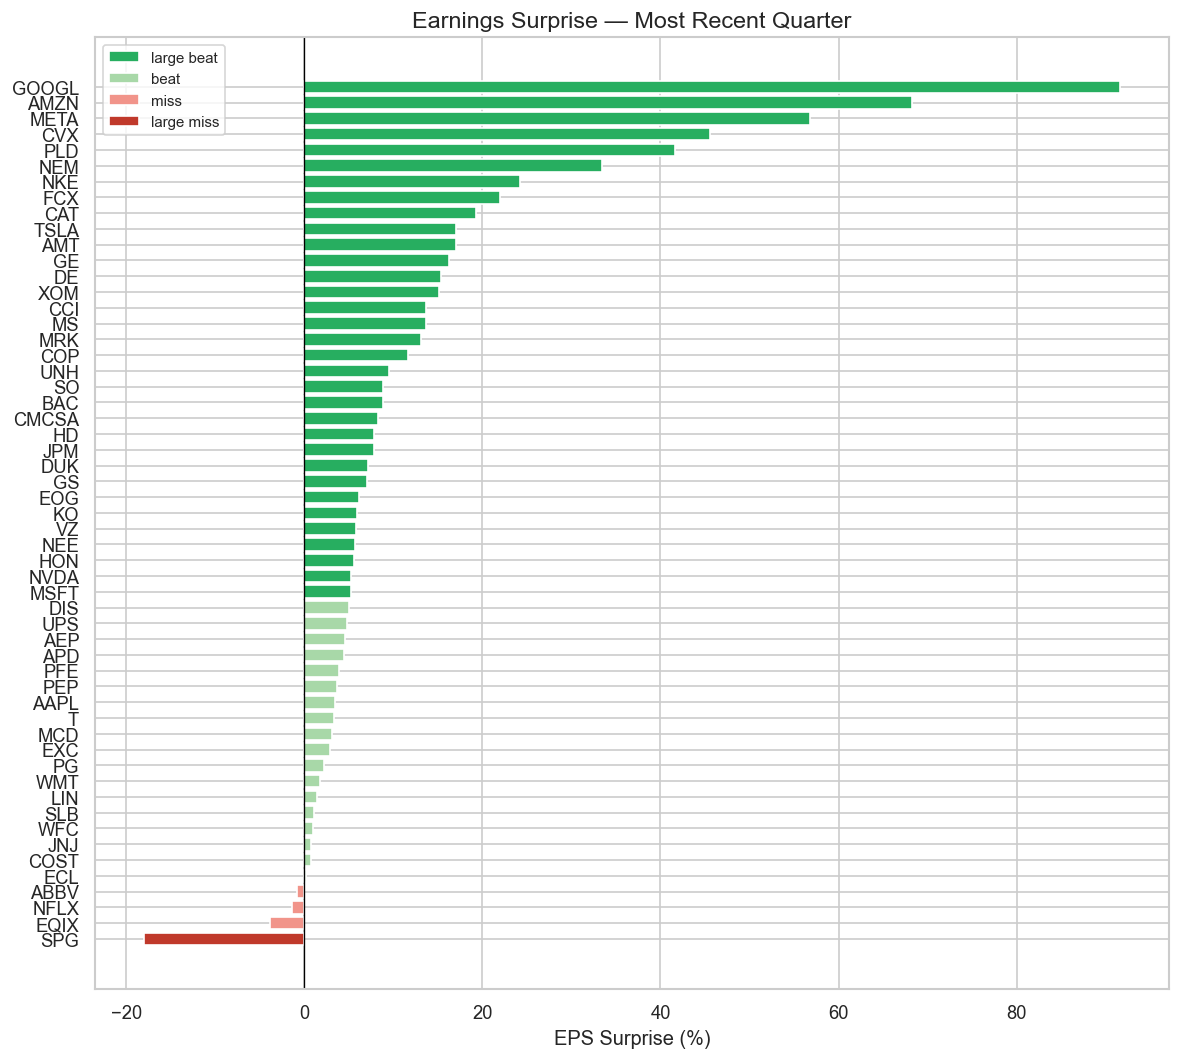

In [9]:
color_map = {
    'large beat': '#27ae60',
    'beat':       '#a8d8a8',
    'miss':       '#f1948a',
    'large miss': '#c0392b',
}
colors = surp_df['outcome'].map(color_map).fillna('#cccccc')

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(surp_df['ticker'], surp_df['surprise_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('EPS Surprise (%)')
ax.set_title('Earnings Surprise — Most Recent Quarter', fontsize=14)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** Persistent positive surprise quarter after quarter signals that analyst estimates are anchored below the true earnings trend — a classic post-earnings announcement drift (PEAD) setup. Stocks with large negative surprises often see gap-down moves that persist. Cross-referencing this with the momentum screen reveals whether the market has already priced in the surprise or a drift opportunity remains.

## 5. Sector Attribution

Monthly equal-weighted sector returns and 12-month cumulative performance — decomposing which sectors drove or dragged returns.  
**SQL:** `DATE_TRUNC`, `LAG` for daily returns, `EXP`/`LN` for geometric compounding, multi-CTE composition.

In [10]:
sql_attr = """
WITH daily_ret AS (
    SELECT
        security_id,
        DATE_TRUNC('month', date)::date AS month,
        adj_close / NULLIF(
            LAG(adj_close) OVER (PARTITION BY security_id ORDER BY date), 0
        ) - 1 AS daily_ret
    FROM daily_prices
    WHERE date >= CURRENT_DATE - INTERVAL '14 months'
),
monthly_ret AS (
    SELECT
        security_id,
        month,
        EXP(SUM(LN(GREATEST(1 + daily_ret, 0.01)))) - 1 AS monthly_ret
    FROM daily_ret
    WHERE daily_ret IS NOT NULL
    GROUP BY security_id, month
),
sector_monthly AS (
    SELECT
        sec.sector_name,
        mr.month,
        AVG(mr.monthly_ret) * 100 AS monthly_return_pct
    FROM monthly_ret mr
    JOIN securities  s   USING (security_id)
    JOIN sectors     sec USING (sector_id)
    GROUP BY sec.sector_name, mr.month
)
SELECT * FROM sector_monthly
WHERE month >= (CURRENT_DATE - INTERVAL '13 months')::date
ORDER BY sector_name, month
"""

attr_df = pd.read_sql(sql_attr, engine)
attr_df['month'] = pd.to_datetime(attr_df['month'])

pivot      = attr_df.pivot(index='month', columns='sector_name', values='monthly_return_pct').dropna()
cumulative = ((1 + pivot / 100).cumprod() - 1) * 100
cumulative.tail()

sector_name,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
month,,,,,,,,,,,
2026-01-01,35.932116,16.910096,21.327979,7.023847,28.732810,44.609060,16.268006,41.014997,3.188862,35.327376,9.014273
2026-02-01,49.644611,19.505227,19.333808,16.564542,39.618247,34.564912,23.951583,58.532895,12.525377,29.054834,19.724496
2026-03-01,37.541261,14.006769,8.747122,9.218105,54.972892,32.372828,20.112769,41.332335,5.442153,24.215724,18.797315
2026-04-01,38.675989,18.770038,10.562520,12.756229,51.363517,44.447290,23.659814,52.125098,14.559763,37.263206,19.492826
2026-05-01,44.315239,15.988545,9.980939,11.656312,45.745361,40.790673,24.732417,51.332716,15.227406,46.124661,15.805861


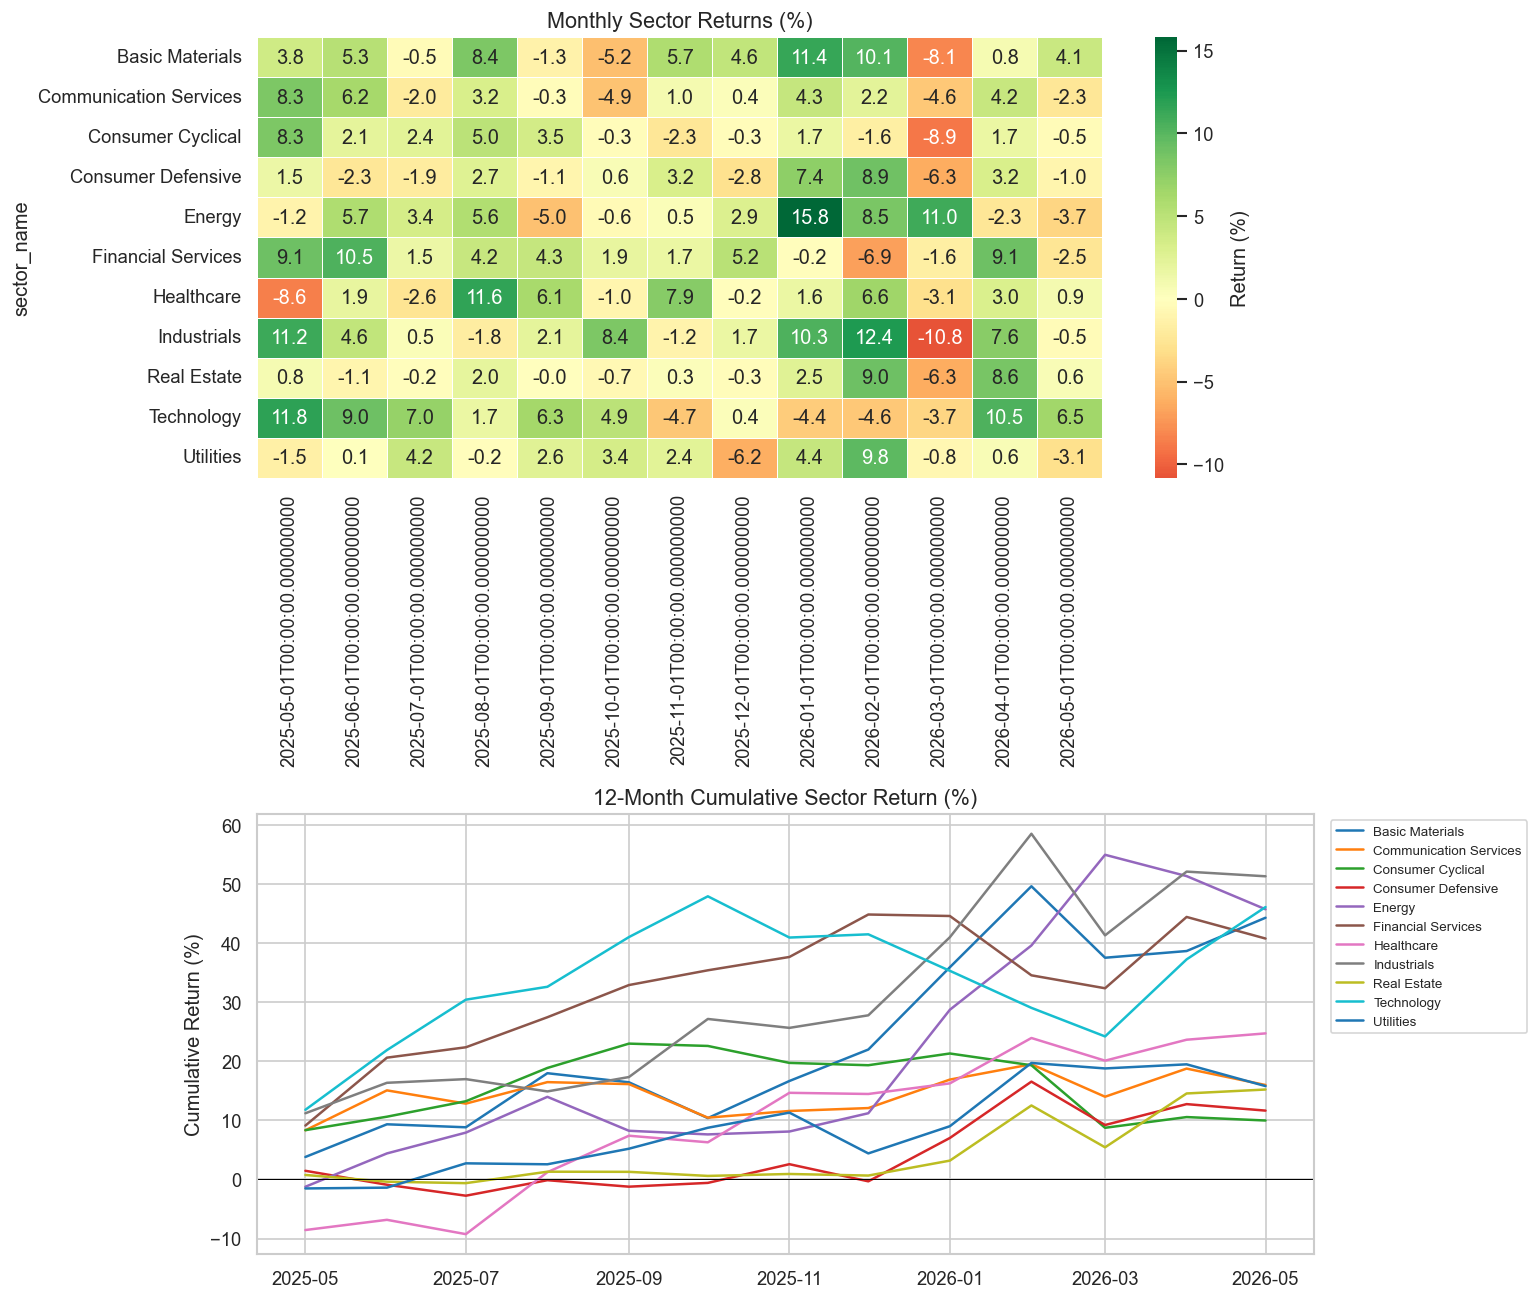

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 11))

sns.heatmap(
    pivot.T.round(1),
    ax=ax1, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
    linewidths=0.4, cbar_kws={'label': 'Return (%)'}
)
ax1.set_title('Monthly Sector Returns (%)', fontsize=13)
ax1.set_xlabel('')

for col in cumulative.columns:
    ax2.plot(cumulative.index, cumulative[col], label=col, linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title('12-Month Cumulative Sector Return (%)', fontsize=13)
ax2.set_ylabel('Cumulative Return (%)')
ax2.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Interpretation:** The heatmap reveals which sectors drove returns each month and where dispersion was widest — months with high cross-sector dispersion are where active sector allocation adds the most value. The cumulative line chart shows persistence: sectors that lead for multiple months typically reflect macro regime shifts (e.g. rising rates favouring Financials, energy supply shocks boosting Energy). Active managers use this decomposition to distinguish sector allocation skill from stock selection skill within a sector.